# Z4 PRS 10-seed statistical $\beta_4$ scan --- analysis

Scan directory `scan_z4_prs_stat/`: $\mu=1$, $N=512$, $L=279.0$ ($dx=0.5449$), PRS from
$t_0$, $\beta_4\in\{0.1,0.3,0.5,0.7,0.9\}$, **10 independent seeds per $\beta_4$**
(50 runs total).

**Why this scan exists:** the long-$\eta$ scan (`scan_z4_prs_long/`,
`Z4_prs_long_analysis.ipynb`) ran a *single* seed per $\beta_4$ to $\eta=150$ and ended
with only $\sim 2$ comoving horizons per side left in the box --- not enough to beat
cosmic (sample) variance on either the wall-area plateau $\mathcal{A}_1(\beta_4)$ or the
late-time log-slope. This scan trades $\eta$-reach ($\eta\le 100$, still $\ge 2.76$
horizons everywhere, $\ge 3$ horizons out to $\eta\approx 92$) for **10 statistically
independent realizations per $\beta_4$**, so we can put an honest seed-to-seed error bar
on both the plateau value and the slope-consistent-with-zero claim.

**Scaling convention (do not use raw `scal`):**
$$\mathcal{A}_1 \equiv \frac{\mathrm{scal}_1}{2aH}\ \ (\text{adjacent walls}), \qquad
  \mathcal{A}_2 \equiv \frac{\mathrm{scal}_2}{2aH}\ \ (\text{opposite walls}),$$
with $a,H$ read from `average_scale_factor.txt` (columns
`[eta, a, a', H]`, all conformal-time quantities --- we use **column 1 ($a$) and column 3
($H$)**, *not* column 2 ($a'$), even though $2aH\approx 2a'\approx 2.0$ here to high
precision since $H_0=\mu$ on a fixed radiation background).

`average_energies.txt` has **11 columns**:
`[eta, Ek1, Ek2, Eg1, Eg2, Ev1, Ev2, Ev3, Etot, scal1, scal2]`, i.e. `scal1` = column 9
(adjacent walls) and `scal2` = column 10 (opposite walls).

**Caveat:** $\beta_4=0.9$ has the thinnest adjacent wall ($\bar\delta_{\rm adj}=1.09$,
only $\approx 2$ cells/wall at this resolution) --- a real pinning/under-resolution risk
that a single seed cannot distinguish from a genuine physical effect. The seed scatter at
$\beta_4=0.9$ is itself diagnostic: large spread = resolution-driven noise.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# Set True for the paper LaTeX style (requires a local LaTeX install); False lets this
# notebook execute anywhere (e.g. CI / headless nodes without latex).
USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

In [2]:
BASE = '/mt/user-batch/dpasari/scan_z4_prs_stat/'

MU = 1.0
N  = 512
L  = 279.0
DX = L / N  # 0.5449

BETAS = [0.1, 0.3, 0.5, 0.7, 0.9]
N_SEEDS = 10
BLAB = {0.1: '1', 0.3: '3', 0.5: '5', 0.7: '7', 0.9: '9'}

# BVP wall widths (dimensionless delta_bar; lattice width = delta_bar/(mu*dx) cells)
D_ADJ = {0.1: 2.38, 0.3: 1.46, 0.5: 1.22, 0.7: 1.11, 0.9: 1.09}
D_OPP = 1.40

_CMAP = plt.cm.winter
COLOR = {b: _CMAP((b - 0.1) / 0.8) for b in BETAS}
LABEL = {b: rf'$\beta_4={b}$' for b in BETAS}

def config_handles(betas):
    return [Line2D([0], [0], color=COLOR[b], lw=2.4, ls='solid', label=LABEL[b])
            for b in betas]

def add_legend(ax, betas, **kw):
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=config_handles(betas), **kw)

def run_dir(beta, seed):
    return os.path.join(BASE, f'results_DWZ4_stat_b40p{BLAB[beta]}_s{seed:02d}')

# Sizing sanity table: cells/wall and horizon coverage over the eta<=100 run.
# horizons(eta) = MU*L/(1+eta); the whole run stays >= 2.76 horizons, and >= 3
# horizons out to eta ~ 92.
print(f"{'beta4':>6s} {'adj(cells)':>11s} {'opp(cells)':>11s} {'hor@100':>9s} {'hor@92':>8s}")
print('-' * 52)
for b in BETAS:
    adj_cells = D_ADJ[b] / (MU * DX)
    opp_cells = D_OPP / (MU * DX)
    hor100 = MU * L / (1 + 100)
    hor92  = MU * L / (1 + 92)
    print(f"{b:>6.1f} {adj_cells:>11.2f} {opp_cells:>11.2f} {hor100:>9.2f} {hor92:>8.2f}")

 beta4  adj(cells)  opp(cells)   hor@100   hor@92
----------------------------------------------------
   0.1        4.37        2.57      2.76     3.00
   0.3        2.68        2.57      2.76     3.00
   0.5        2.24        2.57      2.76     3.00
   0.7        2.04        2.57      2.76     3.00
   0.9        2.00        2.57      2.76     3.00


## Loaders

Per-(`beta`,`seed`) loader returns the four data products or `None` if any file is missing/empty/too-short (`plot-if-ran`: missing seeds are silently skipped downstream).

In [3]:
def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    # Z4: 11 cols -- eta,Ek1,Ek2,Eg1,Eg2,Ev1,Ev2,Ev3,Etot,scal1(adj),scal2(opp)
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 11:
        return None
    return {
        'eta':   data[:, 0], 'Ek_1': data[:, 1], 'Ek_2': data[:, 2],
        'Eg_1':  data[:, 3], 'Eg_2': data[:, 4], 'Ev_1': data[:, 5],
        'Ev_2':  data[:, 6], 'Ev_3': data[:, 7], 'E_tot': data[:, 8],
        'scal1': data[:, 9], 'scal2': data[:, 10],
    }


def load_scalar(path, idx):
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta': data[:, 0], 'phi': data[:, 1], 'phi_prime': data[:, 2],
        'phi2': data[:, 3], 'phi_prime2': data[:, 4], 'rms_phi': data[:, 5],
    }


def load_scale_factor(path):
    # Cols: eta, a, a', H -- use a=col1, H=col3 (NOT a'=col2)
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:, 0], 'a': data[:, 1], 'aprime': data[:, 2], 'H': data[:, 3]}


def load_run(beta, seed):
    path = run_dir(beta, seed)
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    if any(x is None for x in [en, sf, s0, s1]):
        return None
    # require at least a couple of points to be useful downstream
    if len(en['eta']) < 2 or len(sf['eta']) < 2:
        return None
    return {'beta': beta, 'seed': seed, 'energies': en, 'scale_factor': sf,
            'scalar_0': s0, 'scalar_1': s1}

## Load all runs

Discovery: how many of the 10 seeds are present per $\beta$, and how far each ran.

In [4]:
# Discovery: how many of the 10 seeds are present per beta, and their last eta.
RUNS = {}
print(f"{'beta4':>6s} {'n_seeds':>8s} {'last_eta (per seed)'}")
print('-' * 90)
for b in BETAS:
    runs = {}
    last_etas = []
    for s in range(1, N_SEEDS + 1):
        r = load_run(b, s)
        if r is not None:
            runs[s] = r
            last_etas.append(r['energies']['eta'][-1])
    RUNS[b] = runs
    last_str = ', '.join(f'{x:.1f}' for x in last_etas)
    print(f"{b:>6.1f} {len(runs):>8d}   [{last_str}]")

 beta4  n_seeds last_eta (per seed)
------------------------------------------------------------------------------------------
   0.1       10   [99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9]
   0.3       10   [99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9]
   0.5       10   [99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9]
   0.7       10   [99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.9]
   0.9        8   [99.9, 99.9, 99.9, 99.9, 99.9, 99.9, 99.5, 99.9]


## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel: ax.set_ylabel(ylabel, fontsize=24)
    if title:  ax.set_title(title,   fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def phi2_radial(run):
    # <|Phi|^2> = (phi2 of field 0 + phi2 of field 1) / 2
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    return s0['eta'][:n], (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0


def area_param(en_key, run):
    # A = scal / (2 a H) vs eta; a,H interpolated from the scale-factor file
    en, sf = run['energies'], run['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en[en_key] / (2.0 * a_arr * H_arr)
    return en['eta'], A


def breaking_onset_eta(run):
    # first eta where <|Phi|^2> > 0.25 (breaking threshold, used for BOTH Z4 and Z3)
    eta, p2 = phi2_radial(run)
    mask = p2 > 0.25
    return float(eta[mask][0]) if mask.any() else None


def local_logslope(x, y, nbin=60):
    # d ln y / d ln x on coarse log-spaced bins (noise-robust)
    m = (x > 0) & (y > 0) & np.isfinite(y)
    if m.sum() < 10:
        return np.array([]), np.array([])
    lx, ly = np.log(x[m]), np.log(y[m])
    edges = np.linspace(lx[0], lx[-1], nbin + 1)
    idx = np.digitize(lx, edges)
    bx, by = [], []
    for i in range(1, nbin + 1):
        sel = idx == i
        if sel.sum() > 0:
            bx.append(lx[sel].mean()); by.append(ly[sel].mean())
    bx, by = np.array(bx), np.array(by)
    if len(bx) < 4:
        return np.array([]), np.array([])
    return np.exp(0.5*(bx[1:] + bx[:-1])), np.diff(by)/np.diff(bx)


def horizon_guides(ax, n_list=(3, 2.5)):
    # vertical lines where the box drops to n comoving horizons per side: eta = MU*L/n - 1
    for n in n_list:
        eta_n = MU * L / n - 1.0
        if eta_n < ax.get_xlim()[1]:
            ax.axvline(eta_n, color='k', ls=':', lw=1.0, alpha=0.5)

## Seed-aggregation helper

`seed_mean_std(beta, quantity_fn)`: for each available seed compute `quantity_fn(run) -> (eta, y)`, interpolate every seed onto a common $\eta$ grid, and return the across-seed mean and std (NaN-tolerant of partial coverage).

In [6]:
def seed_mean_std(beta, quantity_fn, n_grid=400):
    runs = RUNS.get(beta, {})
    curves = []
    eta_lo, eta_hi = None, None
    for s, run in runs.items():
        try:
            eta, y = quantity_fn(run)
        except Exception:
            continue
        eta = np.asarray(eta); y = np.asarray(y)
        if eta.size < 2:
            continue
        curves.append((eta, y))
        lo, hi = eta[0], eta[-1]
        eta_lo = lo if eta_lo is None else min(eta_lo, lo)
        eta_hi = hi if eta_hi is None else max(eta_hi, hi)
    if not curves or eta_lo is None or eta_hi <= eta_lo:
        return np.array([]), np.array([]), np.array([]), 0

    eta_grid = np.linspace(eta_lo, eta_hi, n_grid)
    stacked = np.full((len(curves), n_grid), np.nan)
    for i, (eta, y) in enumerate(curves):
        # only interpolate within this seed's own eta-range; outside -> NaN
        in_range = (eta_grid >= eta[0]) & (eta_grid <= eta[-1])
        stacked[i, in_range] = np.interp(eta_grid[in_range], eta, y)

    mean = np.nanmean(stacked, axis=0)
    std  = np.nanstd(stacked, axis=0)
    n_seeds_at = np.sum(~np.isnan(stacked), axis=0)
    return eta_grid, mean, std, len(curves)

## 1. Health: radial diagnostic $\langle|\Phi|^2\rangle$ and mean-field drift

**Left:** $\langle|\Phi|^2\rangle = (\langle h^2\rangle + \langle a^2\rangle)/2$; guide at $0.5$ = vacuum, dashed at $0.25$ = **breaking/melt marker** (the reliable criterion for both Z4 and Z3 -- *not* $E_{V_1}<0$).

**Right:** $|\langle\Phi\rangle| = \sqrt{\langle h\rangle^2+\langle a\rangle^2}$ -- growth toward $\mathcal{O}(1)$ signals finite-volume domain depletion.

Each curve is the across-seed mean; the shaded band is $\pm1\sigma$ across the available seeds at that $\beta$.

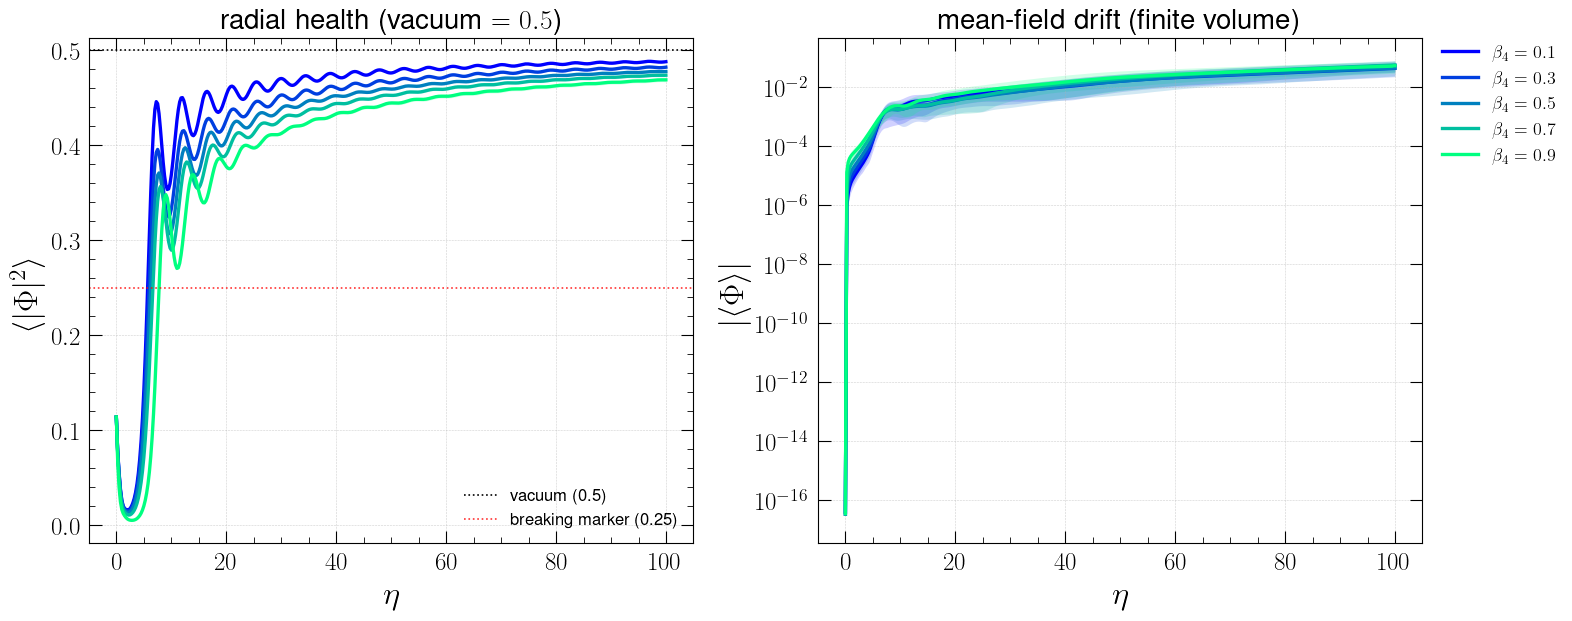

In [7]:
def drift_curve(run):
    # |<Phi>| = sqrt(<h>^2 + <a>^2); field 1 interpolated onto field 0's eta
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    eta = s0['eta'][:n]
    phi1 = np.interp(eta, s1['eta'], s1['phi'])
    return eta, np.sqrt(s0['phi'][:n]**2 + phi1**2)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, phi2_radial)
    if eta.size:
        axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)
    etad, meand, stdd, nd = seed_mean_std(b, drift_curve)
    if etad.size:
        axes[1].plot(etad, meand, color=COLOR[b], lw=2.4)
        axes[1].fill_between(etad, meand - stdd, meand + stdd, color=COLOR[b], alpha=0.18, lw=0)

axes[0].axhline(0.5,  color='k', ls=':', lw=1.2, label='vacuum (0.5)')
axes[0].axhline(0.25, color='r', ls=':', lw=1.2, alpha=0.8, label='breaking marker (0.25)')
axes[0].legend(fontsize=12, frameon=False)
axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$\langle|\Phi|^2\rangle$',
         title=r'radial health (vacuum $=0.5$)')
paper_ax(axes[1], ylabel=r'$|\langle\Phi\rangle|$',
         title=r'mean-field drift (finite volume)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 2. Potential energies $E_{V_1}$, $E_{V_2}$, $E_{V_3}$

$E_{V_1}=-\mu^2\langle|\Phi|^2\rangle + V_0$ with a $\beta$-dependent vacuum offset $V_0$, so $E_{V_1}$ can stay positive even in the broken vacuum (e.g. $\beta=0.9$). Use the $\langle|\Phi|^2\rangle>0.25$ marker for breaking, **not** the sign of $E_{V_1}$. Right panel: quartic terms (solid $E_{V_2}$, dashed $E_{V_3}$). Bands are seed $\pm1\sigma$.

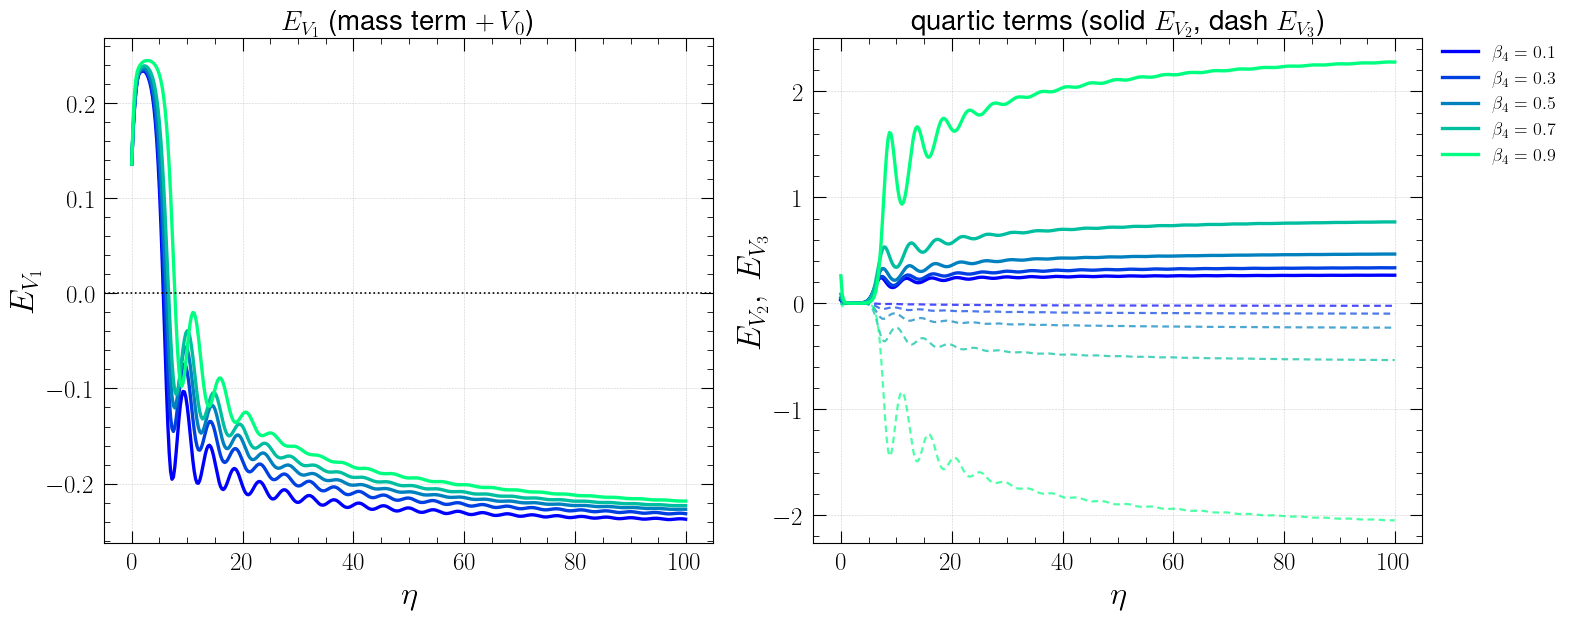

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    e1, m1, s1, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_1']))
    if e1.size:
        axes[0].plot(e1, m1, color=COLOR[b], lw=2.4)
        axes[0].fill_between(e1, m1 - s1, m1 + s1, color=COLOR[b], alpha=0.18, lw=0)
    e2, m2, s2, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_2']))
    if e2.size:
        axes[1].plot(e2, m2, color=COLOR[b], lw=2.4)
        axes[1].fill_between(e2, m2 - s2, m2 + s2, color=COLOR[b], alpha=0.18, lw=0)
    e3, m3, s3, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_3']))
    if e3.size:
        axes[1].plot(e3, m3, color=COLOR[b], ls=(0, (3, 2)), lw=1.6, alpha=0.7)

axes[0].axhline(0, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$E_{V_1}$', title=r'$E_{V_1}$ (mass term $+\,V_0$)')
paper_ax(axes[1], ylabel=r'$E_{V_2},\;E_{V_3}$',
         title=r'quartic terms (solid $E_{V_2}$, dash $E_{V_3}$)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 3. Kinetic and gradient energies

Both scalar components summed; log--log. Seed mean $\pm1\sigma$ band per $\beta$.

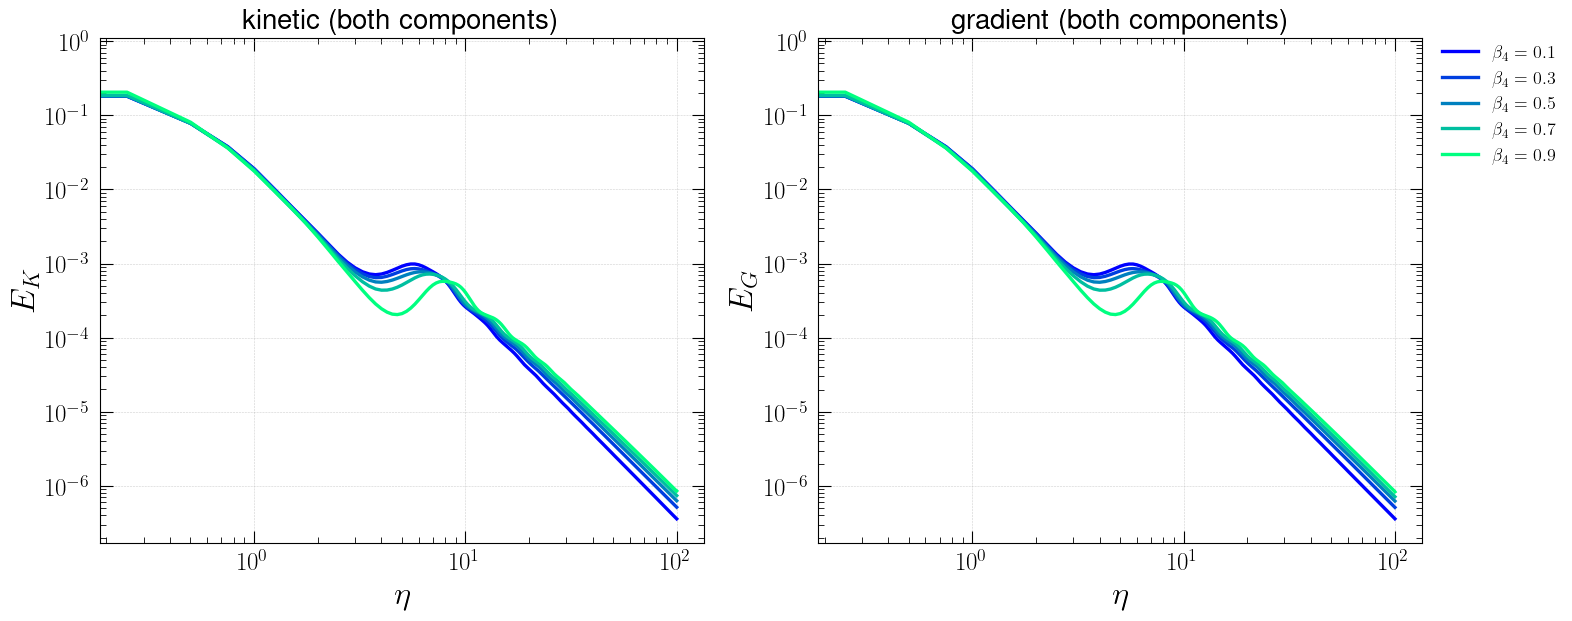

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    ek, mk, sk, _ = seed_mean_std(
        b, lambda r: (r['energies']['eta'], r['energies']['Ek_1'] + r['energies']['Ek_2']))
    if ek.size:
        axes[0].plot(ek, mk, color=COLOR[b], lw=2.4)
        axes[0].fill_between(ek, np.clip(mk - sk, 1e-30, None), mk + sk,
                             color=COLOR[b], alpha=0.18, lw=0)
    eg, mg, sg, _ = seed_mean_std(
        b, lambda r: (r['energies']['eta'], r['energies']['Eg_1'] + r['energies']['Eg_2']))
    if eg.size:
        axes[1].plot(eg, mg, color=COLOR[b], lw=2.4)
        axes[1].fill_between(eg, np.clip(mg - sg, 1e-30, None), mg + sg,
                             color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
paper_ax(axes[0], ylabel=r'$E_K$', title=r'kinetic (both components)')
paper_ax(axes[1], ylabel=r'$E_G$', title=r'gradient (both components)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 4. Scalar-field means $\langle h\rangle$, $\langle a\rangle$

Per-component volume-averaged field. Here the band is **seed scatter** ($\pm1\sigma$ across seeds), *not* the within-volume spatial rms: each seed's mean field drifts to a random sign under finite-volume depletion, so the seed mean sits near $0$ with a band that widens as domains are depleted.

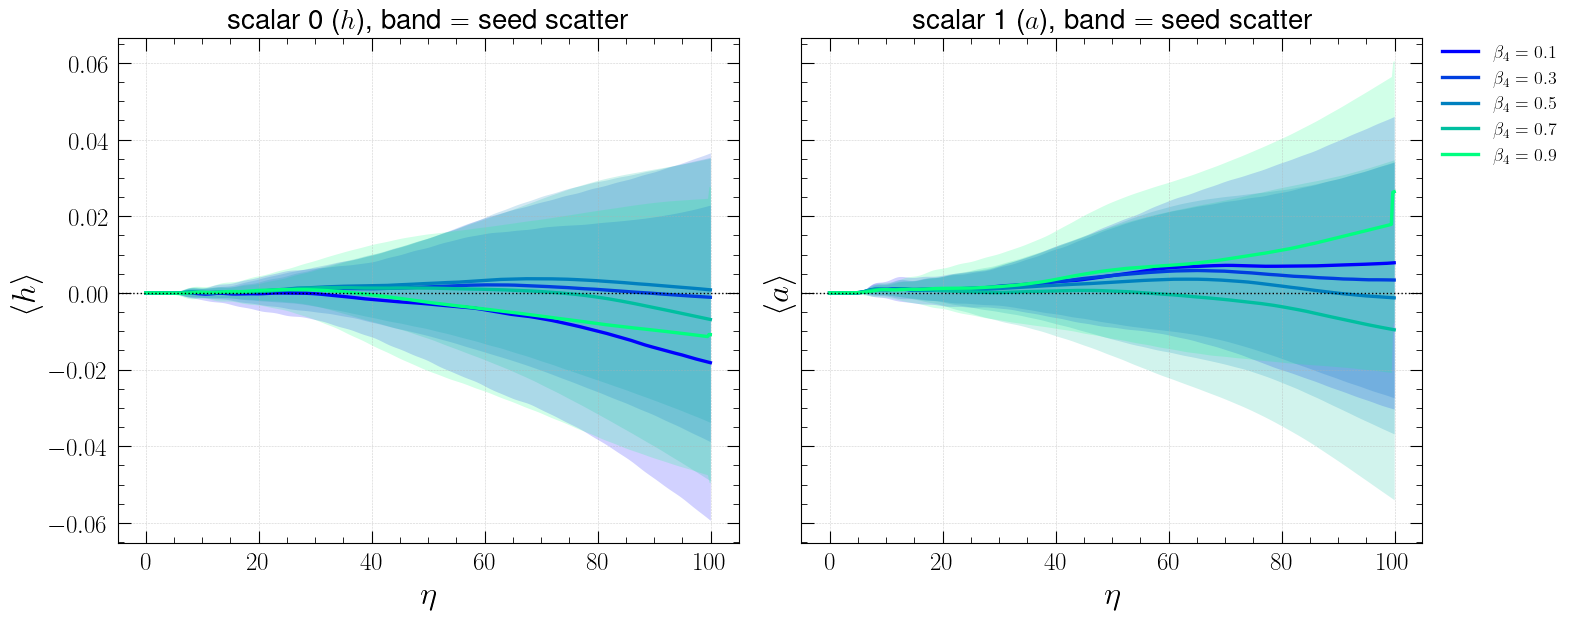

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
for b in BETAS:
    eh, mh, sh, _ = seed_mean_std(b, lambda r: (r['scalar_0']['eta'], r['scalar_0']['phi']))
    if eh.size:
        axes[0].plot(eh, mh, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eh, mh - sh, mh + sh, color=COLOR[b], alpha=0.18, lw=0)
    ea, ma, sa, _ = seed_mean_std(b, lambda r: (r['scalar_1']['eta'], r['scalar_1']['phi']))
    if ea.size:
        axes[1].plot(ea, ma, color=COLOR[b], lw=2.4)
        axes[1].fill_between(ea, ma - sa, ma + sa, color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    ax.axhline(0, color='k', ls=':', lw=1.0)
paper_ax(axes[0], ylabel=r'$\langle h\rangle$', title=r'scalar 0 ($h$), band $=$ seed scatter')
paper_ax(axes[1], ylabel=r'$\langle a\rangle$', title=r'scalar 1 ($a$), band $=$ seed scatter')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 5. Scale factor and Hubble

Sanity panel: $a(\eta)$ and the conformal Hubble $\mathcal{H}=a'/a$ read from `average_scale_factor.txt`. This is the **fixed radiation background** ($H_0=\mu$), identical for every $\beta$ and every seed, so all curves overlap into one line each ($a$ rises linearly, $\mathcal{H}\propto 1/a$). It is what makes $2aH=2$ exactly, which is why $\mathcal{A}\equiv\mathrm{scal}/(2aH)$ below is just $\mathrm{scal}/2$.

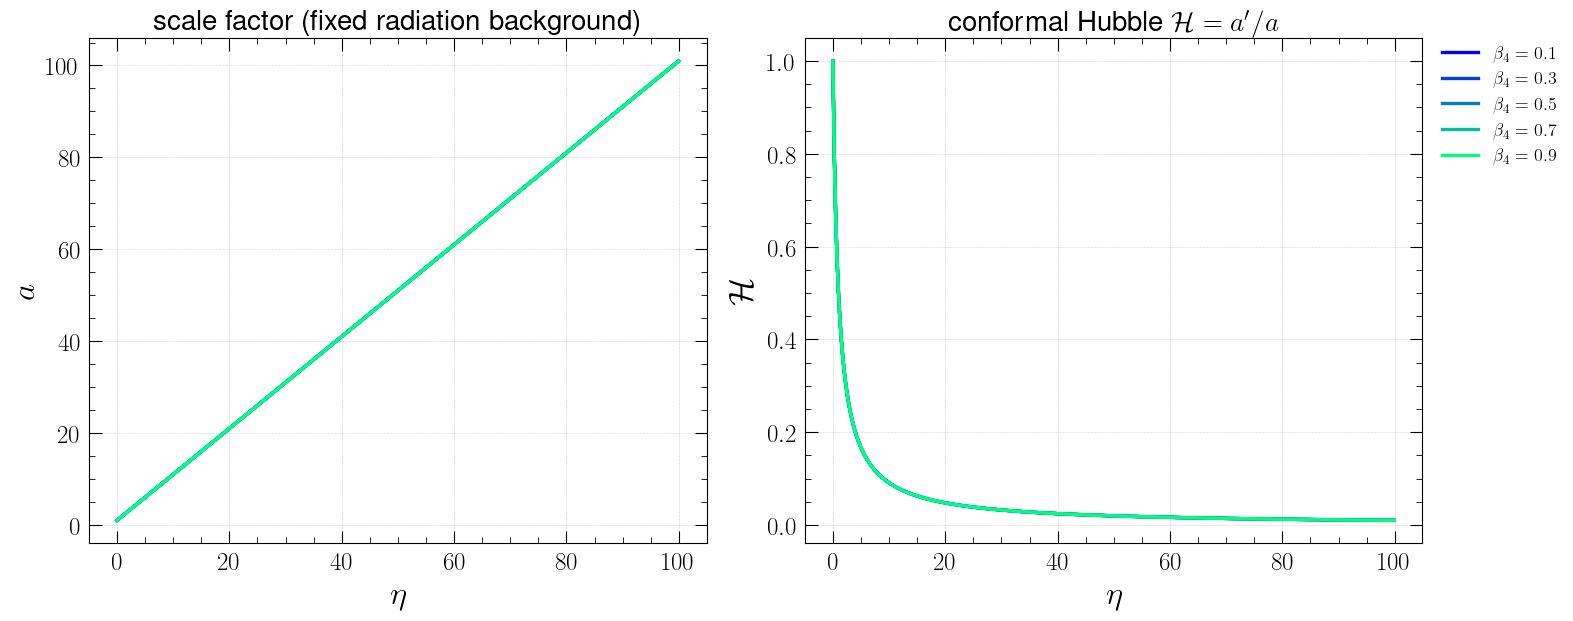

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    ea, ma, sa, _ = seed_mean_std(b, lambda r: (r['scale_factor']['eta'], r['scale_factor']['a']))
    if ea.size:
        axes[0].plot(ea, ma, color=COLOR[b], lw=2.4)
    eh, mh, sh, _ = seed_mean_std(b, lambda r: (r['scale_factor']['eta'], r['scale_factor']['H']))
    if eh.size:
        axes[1].plot(eh, mh, color=COLOR[b], lw=2.4)

paper_ax(axes[0], ylabel=r'$a$', title=r'scale factor (fixed radiation background)')
paper_ax(axes[1], ylabel=r"$\mathcal{H}$", title=r"conformal Hubble $\mathcal{H}=a'/a$")
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 6. Wall-area parameters $\mathcal{A}_1$ (adjacent) and $\mathcal{A}_2$ (opposite)

$\mathcal{A}_1\equiv\mathrm{scal}_1/(2aH)$ (adjacent walls), $\mathcal{A}_2\equiv\mathrm{scal}_2/(2aH)$ (opposite walls); log--log, seed mean $\pm1\sigma$. Dotted verticals mark the 3- and 2.5-horizon points. A plateau at $\mathcal{A}\sim\mathcal{O}(1)$ is the scaling signature.

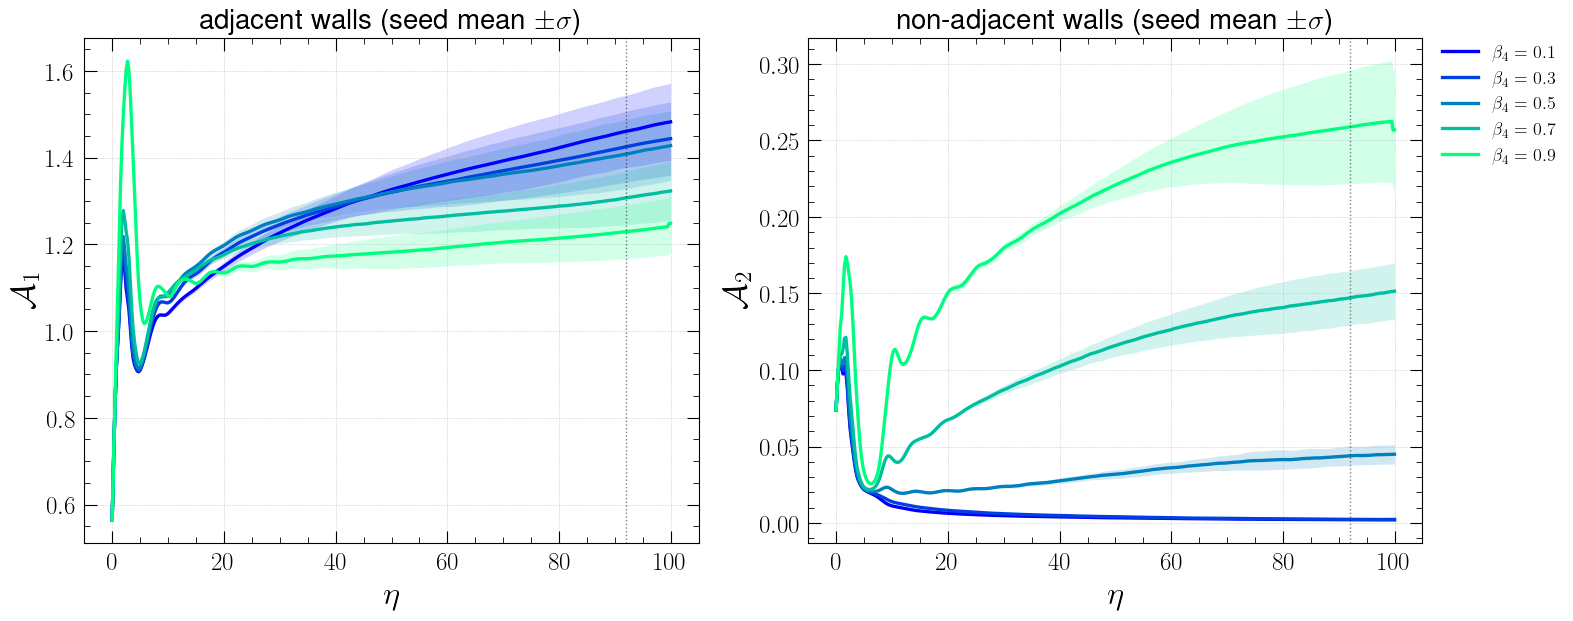

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, lambda r: area_param('scal1', r))
    if eta.size == 0:
        continue
    axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
    axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

    eta2, mean2, std2, n2 = seed_mean_std(b, lambda r: area_param('scal2', r))
    if eta2.size == 0:
        continue
    axes[1].plot(eta2, mean2, color=COLOR[b], lw=2.4)
    axes[1].fill_between(eta2, mean2 - std2, mean2 + std2, color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    # ax.set_xscale('log'); ax.set_yscale('log')
    
    horizon_guides(ax)
paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'adjacent walls (seed mean $\pm\sigma$)')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_2$', title=r'non-adjacent walls (seed mean $\pm\sigma$)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 7. Local logarithmic slope ${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$

Computed **per seed first** (only $\eta>1.5\,\eta_{\rm break}$ to skip the transient), then aggregated across seeds. Scaling $\Leftrightarrow$ slope $\to0$ (horizontal guide).

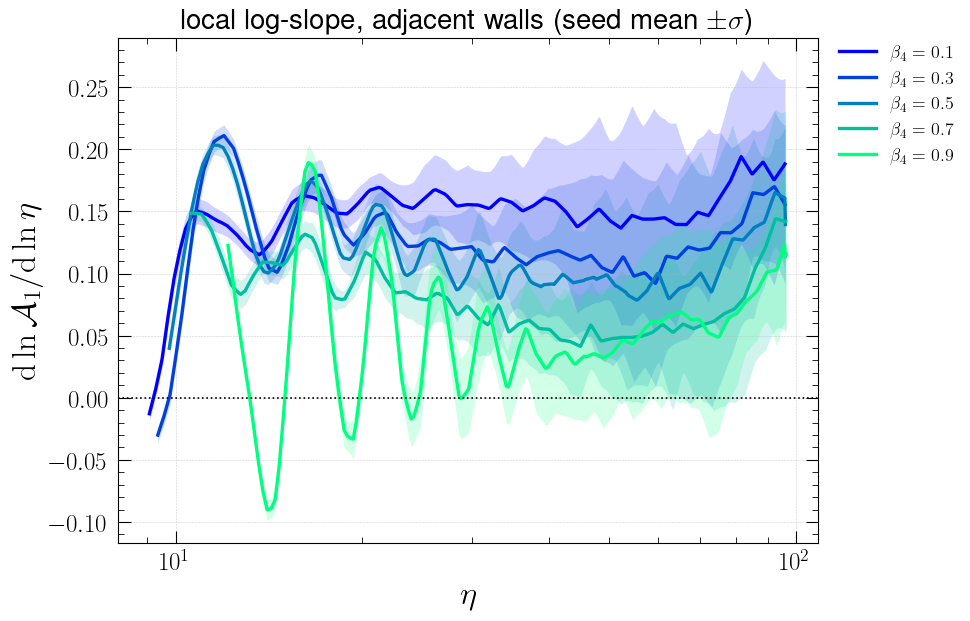

In [13]:
def logslope_curve(run):
    eta, A = area_param('scal1', run)
    eb = breaking_onset_eta(run)
    if eb is not None:
        sel = eta > 1.5 * eb
    else:
        sel = eta > 0
    return local_logslope(eta[sel], A[sel])


fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, logslope_curve)
    if eta.size == 0:
        continue
    ax.plot(eta, mean, color=COLOR[b], lw=2.4)
    ax.fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

ax.axhline(0, color='k', ls=':', lw=1.2)
ax.set_xscale('log')
paper_ax(ax, ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$',
         title=r'local log-slope, adjacent walls (seed mean $\pm\sigma$)')
add_legend(ax, BETAS)
plt.tight_layout(); plt.show()

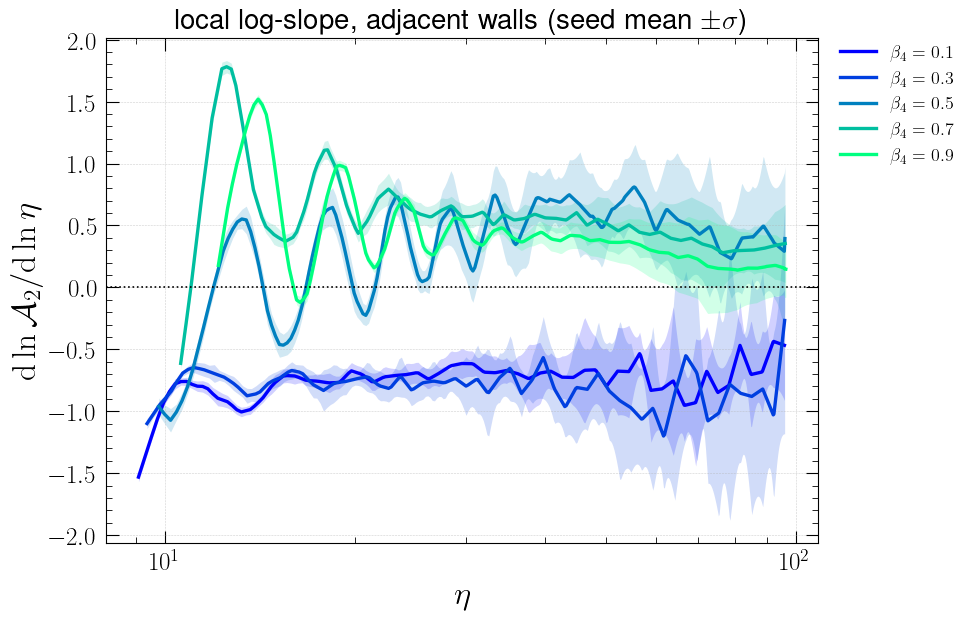

In [ ]:
def logslope_curve(run):
    eta, A = area_param('scal2', run)
    eb = breaking_onset_eta(run)
    if eb is not None:
        sel = eta > 1.5 * eb
    else:
        sel = eta > 0
    return local_logslope(eta[sel], A[sel])


fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, logslope_curve)
    if eta.size == 0:
        continue
    ax.plot(eta, mean, color=COLOR[b], lw=2.4)
    ax.fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

ax.axhline(0, color='k', ls=':', lw=1.2)
ax.set_xscale('log')
paper_ax(ax, ylabel=r'${\rm d}\ln\mathcal{A}_2/{\rm d}\ln\eta$',
         title=r'local log-slope, non-adjacent walls (seed mean $\pm\sigma$)')
add_legend(ax, BETAS)
plt.tight_layout(); plt.show()

## 8. Slope-in-window vs $\beta$ --- THE key result

Per seed, fit a line to $\ln\mathcal{A}_1$ vs $\ln\eta$ over $\eta\in[20,\eta_{\rm hi}]$ ($\eta_{\rm hi}$ = the 2.5-horizon $\eta$, in practice the run's last $\eta\approx100$). Errorbar = across-seed mean $\pm1\sigma$. A slope consistent with $0$ within error means scaling.

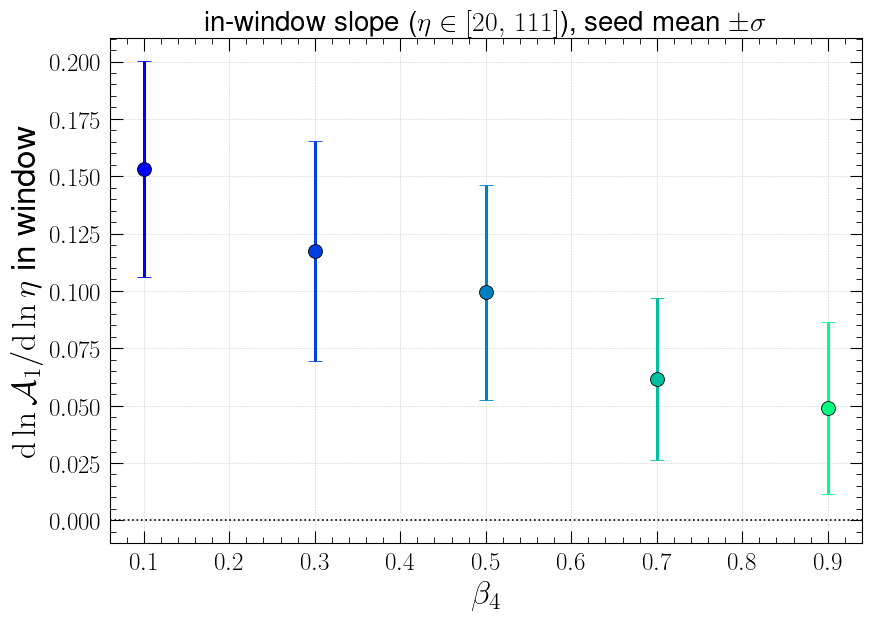

 beta4  n_seeds  slope_mean  slope_std
----------------------------------------
   0.1       10      0.1532     0.0471
   0.3       10      0.1173     0.0480
   0.5       10      0.0994     0.0469
   0.7       10      0.0616     0.0353
   0.9        8      0.0490     0.0377


In [15]:
ETA_LO = 20.0
ETA_HI_NOM = MU * L / 2.5 - 1.0  # ~110.6; in practice capped by each run's last eta (~100)

def fit_logslope_window(run, eta_lo=ETA_LO, eta_hi=ETA_HI_NOM):
    eta, A = area_param('scal1', run)
    sel = (eta >= eta_lo) & (eta <= eta_hi) & (A > 0)
    if sel.sum() < 5:
        return np.nan
    x = np.log(eta[sel]); y = np.log(A[sel])
    X = np.column_stack([np.ones_like(x), x])
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(coeffs[1])


slope_mean = {}
slope_std  = {}
slope_n    = {}
for b in BETAS:
    vals = [fit_logslope_window(r) for r in RUNS.get(b, {}).values()]
    vals = np.array([v for v in vals if np.isfinite(v)])
    slope_mean[b] = np.nanmean(vals) if vals.size else np.nan
    slope_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    slope_n[b]    = vals.size

fig, ax = plt.subplots(figsize=(9, 6.5))
xs = BETAS
ys = [slope_mean[b] for b in xs]
es = [slope_std[b]  for b in xs]
for b in BETAS:
    ax.errorbar([b], [slope_mean[b]], yerr=[slope_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
ax.axhline(0, color='k', ls=':', lw=1.2)
paper_ax(ax, xlabel=r'$\beta_4$',
         ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$ in window',
         title=rf'in-window slope ($\eta\in[{ETA_LO:.0f},\,{ETA_HI_NOM:.0f}]$), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'slope_mean':>11s} {'slope_std':>10s}")
print('-' * 40)
for b in BETAS:
    print(f"{b:>6.1f} {slope_n[b]:>8d} {slope_mean[b]:>11.4f} {slope_std[b]:>10.4f}")

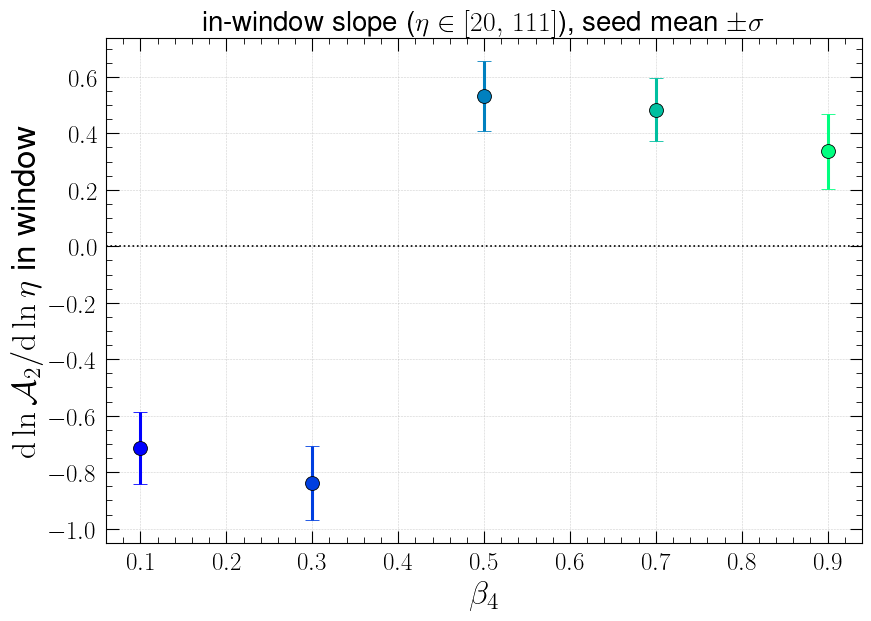

 beta4  n_seeds  slope_mean  slope_std
----------------------------------------
   0.1       10     -0.7144     0.1272
   0.3       10     -0.8382     0.1325
   0.5       10      0.5323     0.1237
   0.7       10      0.4835     0.1112
   0.9        8      0.3363     0.1328


In [16]:
ETA_LO = 20.0
ETA_HI_NOM = MU * L / 2.5 - 1.0  # ~110.6; in practice capped by each run's last eta (~100)

def fit_logslope_window(run, eta_lo=ETA_LO, eta_hi=ETA_HI_NOM):
    eta, A = area_param('scal2', run)
    sel = (eta >= eta_lo) & (eta <= eta_hi) & (A > 0)
    if sel.sum() < 5:
        return np.nan
    x = np.log(eta[sel]); y = np.log(A[sel])
    X = np.column_stack([np.ones_like(x), x])
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(coeffs[1])


slope_mean = {}
slope_std  = {}
slope_n    = {}
for b in BETAS:
    vals = [fit_logslope_window(r) for r in RUNS.get(b, {}).values()]
    vals = np.array([v for v in vals if np.isfinite(v)])
    slope_mean[b] = np.nanmean(vals) if vals.size else np.nan
    slope_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    slope_n[b]    = vals.size

fig, ax = plt.subplots(figsize=(9, 6.5))
xs = BETAS
ys = [slope_mean[b] for b in xs]
es = [slope_std[b]  for b in xs]
for b in BETAS:
    ax.errorbar([b], [slope_mean[b]], yerr=[slope_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
ax.axhline(0, color='k', ls=':', lw=1.2)
paper_ax(ax, xlabel=r'$\beta_4$',
         ylabel=r'${\rm d}\ln\mathcal{A}_2/{\rm d}\ln\eta$ in window',
         title=rf'in-window slope ($\eta\in[{ETA_LO:.0f},\,{ETA_HI_NOM:.0f}]$), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'slope_mean':>11s} {'slope_std':>10s}")
print('-' * 40)
for b in BETAS:
    print(f"{b:>6.1f} {slope_n[b]:>8d} {slope_mean[b]:>11.4f} {slope_std[b]:>10.4f}")

## 9. $\mathcal{A}_1$ plateau value vs $\beta$

Seed mean $\pm1\sigma$ of $\mathcal{A}_1$ at the fiducial late $\eta=80$ (interpolated per seed), errorbar vs $\beta$.

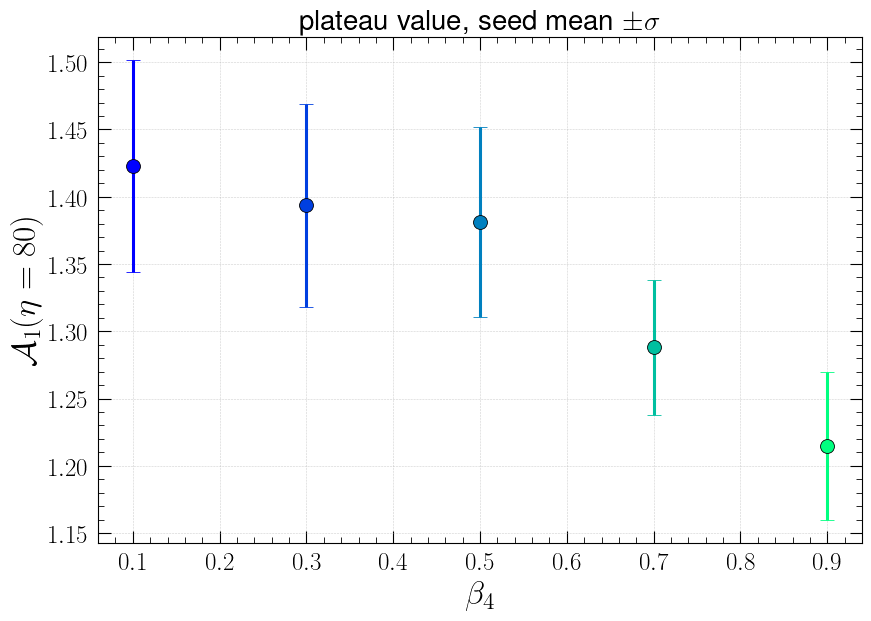

 beta4  n_seeds   A1_mean   A1_std
------------------------------------
   0.1       10    1.4229   0.0787
   0.3       10    1.3937   0.0754
   0.5       10    1.3810   0.0708
   0.7       10    1.2882   0.0502
   0.9        8    1.2144   0.0550


In [17]:
ETA_FID = 80.0

def A1_at_eta(run, eta_fid=ETA_FID):
    eta, A = area_param('scal1', run)
    if eta.size < 2 or eta_fid < eta[0] or eta_fid > eta[-1]:
        return np.nan
    return float(np.interp(eta_fid, eta, A))

plateau_mean = {}
plateau_std  = {}
plateau_n    = {}
for b in BETAS:
    vals = [A1_at_eta(r) for r in RUNS.get(b, {}).values()]
    vals = np.array([v for v in vals if np.isfinite(v)])
    plateau_mean[b] = np.nanmean(vals) if vals.size else np.nan
    plateau_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    plateau_n[b]    = vals.size

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [plateau_mean[b]], yerr=[plateau_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
paper_ax(ax, xlabel=r'$\beta_4$', ylabel=rf'$\mathcal{{A}}_1(\eta={ETA_FID:.0f})$',
         title=r'plateau value, seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'A1_mean':>9s} {'A1_std':>8s}")
print('-' * 36)
for b in BETAS:
    print(f"{b:>6.1f} {plateau_n[b]:>8d} {plateau_mean[b]:>9.4f} {plateau_std[b]:>8.4f}")

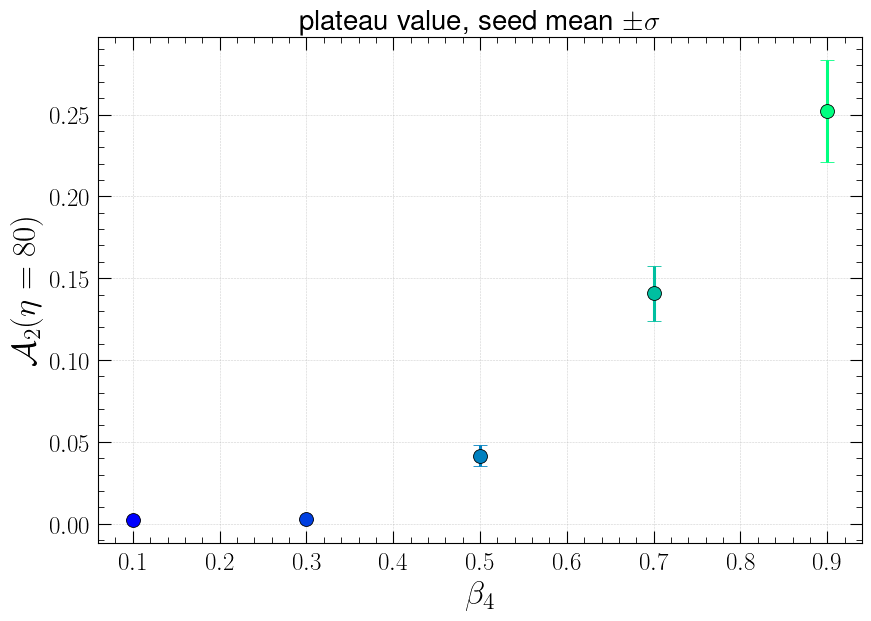

 beta4  n_seeds   A1_mean   A1_std
------------------------------------
   0.1       10    0.0024   0.0003
   0.3       10    0.0027   0.0004
   0.5       10    0.0415   0.0064
   0.7       10    0.1408   0.0168
   0.9        8    0.2522   0.0311


In [18]:
ETA_FID = 80.0

def A1_at_eta(run, eta_fid=ETA_FID):
    eta, A = area_param('scal2', run)
    if eta.size < 2 or eta_fid < eta[0] or eta_fid > eta[-1]:
        return np.nan
    return float(np.interp(eta_fid, eta, A))

plateau_mean = {}
plateau_std  = {}
plateau_n    = {}
for b in BETAS:
    vals = [A1_at_eta(r) for r in RUNS.get(b, {}).values()]
    vals = np.array([v for v in vals if np.isfinite(v)])
    plateau_mean[b] = np.nanmean(vals) if vals.size else np.nan
    plateau_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    plateau_n[b]    = vals.size

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [plateau_mean[b]], yerr=[plateau_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
paper_ax(ax, xlabel=r'$\beta_4$', ylabel=rf'$\mathcal{{A}}_2(\eta={ETA_FID:.0f})$',
         title=r'plateau value, seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'A1_mean':>9s} {'A1_std':>8s}")
print('-' * 36)
for b in BETAS:
    print(f"{b:>6.1f} {plateau_n[b]:>8d} {plateau_mean[b]:>9.4f} {plateau_std[b]:>8.4f}")

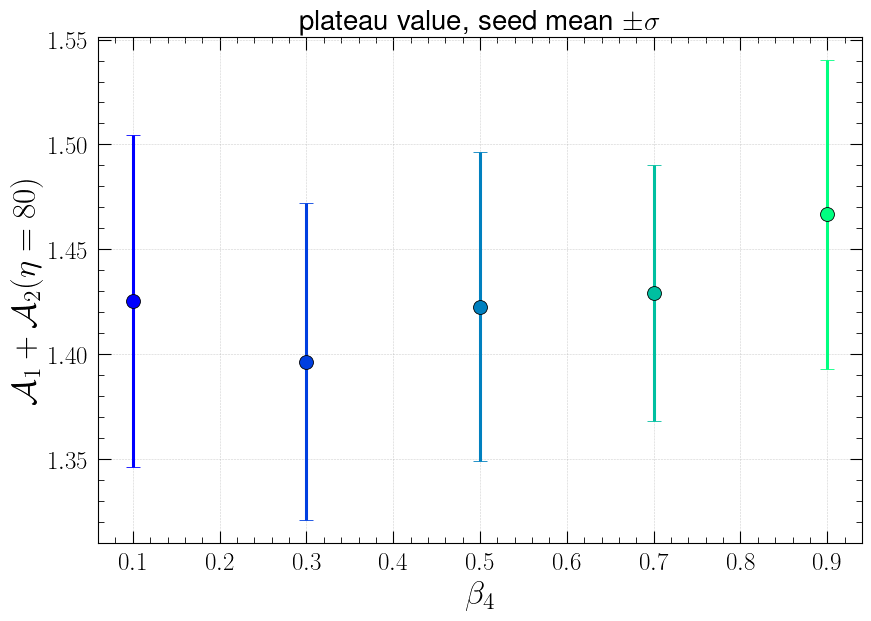

 beta4  n_seeds   A1_mean   A1_std
------------------------------------
   0.1       10    1.4252   0.0791
   0.3       10    1.3964   0.0758
   0.5       10    1.4225   0.0738
   0.7       10    1.4290   0.0612
   0.9        8    1.4666   0.0736


In [25]:
ETA_FID = 80.0

def A1_at_eta(run, eta_fid=ETA_FID):
    eta, A1 = area_param('scal1', run)
    eta, A2 = area_param('scal2', run)
    A = A1+A2
    if eta.size < 2 or eta_fid < eta[0] or eta_fid > eta[-1]:
        return np.nan
    return float(np.interp(eta_fid, eta, A))

plateau_mean = {}
plateau_std  = {}
plateau_n    = {}
for b in BETAS:
    vals = [A1_at_eta(r) for r in RUNS.get(b, {}).values()]
    vals = np.array([v for v in vals if np.isfinite(v)])
    plateau_mean[b] = np.nanmean(vals) if vals.size else np.nan
    plateau_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    plateau_n[b]    = vals.size

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [plateau_mean[b]], yerr=[plateau_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
paper_ax(ax, xlabel=r'$\beta_4$', ylabel=rf'$\mathcal{{A}}_1+\mathcal{{A}}_2(\eta={ETA_FID:.0f})$',
         title=r'plateau value, seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'A1_mean':>9s} {'A1_std':>8s}")
print('-' * 36)
for b in BETAS:
    print(f"{b:>6.1f} {plateau_n[b]:>8d} {plateau_mean[b]:>9.4f} {plateau_std[b]:>8.4f}")

## 10. Opposite-wall $\mathcal{A}_2$ and the ratio $\mathcal{A}_2/\mathcal{A}_1$ (Z4 only)

$\bar\sigma_{\rm opp}=2\bar\sigma_{\rm adj}$ exactly at $\beta_4=1/3$: below this the opposite ($\pi$-jump) walls split into two adjacent walls (decaying ratio); above it they are bound (stable/rising ratio). Left: $\mathcal{A}_2$ seed mean $\pm1\sigma$; right: the ratio across the $\beta_4=1/3$ transition.

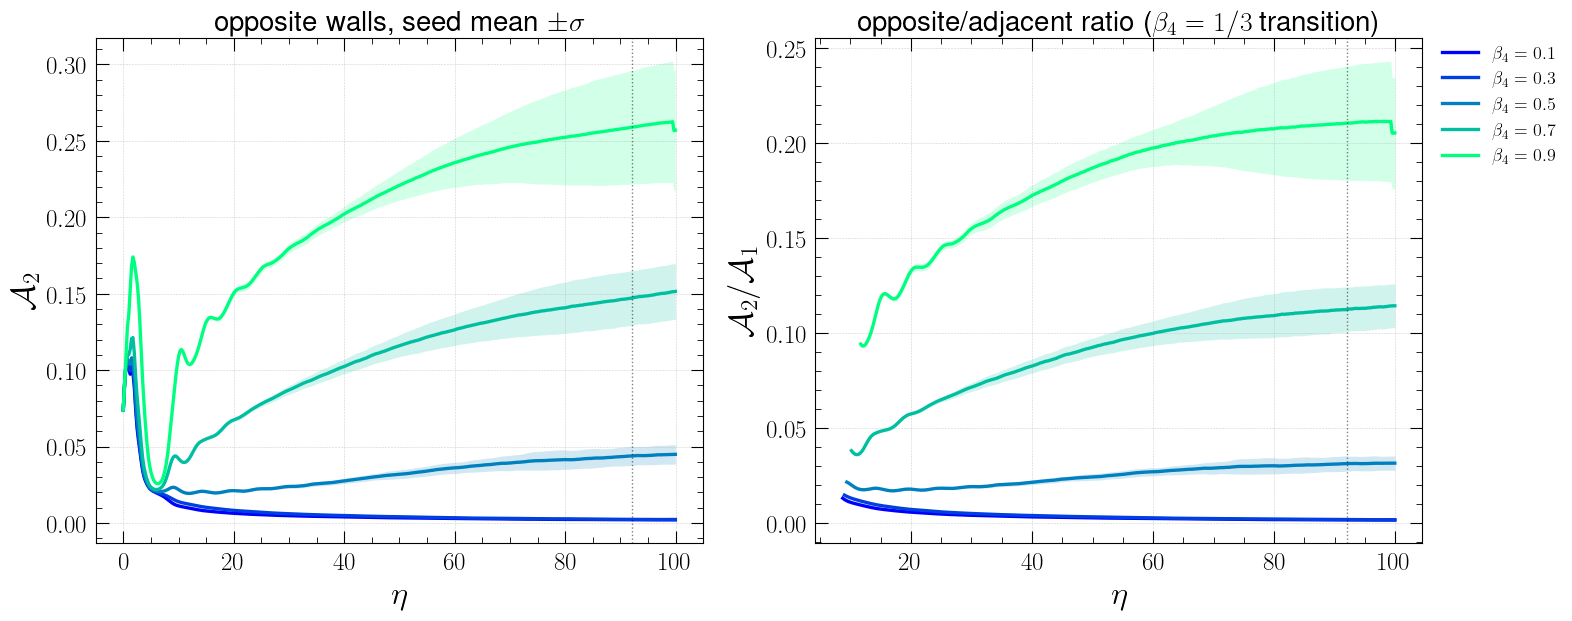

In [20]:
def ratio_curve(run):
    eta1, A1 = area_param('scal1', run)
    eta2, A2 = area_param('scal2', run)
    n = min(len(eta1), len(eta2))
    eta = eta1[:n]
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = A2[:n] / A1[:n]
    eb = breaking_onset_eta(run)
    sel = eta > (1.5 * eb if eb is not None else 0)
    return eta[sel], ratio[sel]


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, lambda r: area_param('scal2', r))
    if eta.size:
        axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

    etar, meanr, stdr, nr = seed_mean_std(b, ratio_curve)
    if etar.size:
        axes[1].plot(etar, meanr, color=COLOR[b], lw=2.4)
        axes[1].fill_between(etar, meanr - stdr, meanr + stdr, color=COLOR[b], alpha=0.18, lw=0)

# axes[0].set_xscale('log'); axes[0].set_yscale('log')
# axes[1].set_xscale('log'); axes[1].set_yscale('log')
for ax in axes:
    horizon_guides(ax)
paper_ax(axes[0], ylabel=r'$\mathcal{A}_2$', title=r'opposite walls, seed mean $\pm\sigma$')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_2/\mathcal{A}_1$',
         title=r'opposite/adjacent ratio ($\beta_4=1/3$ transition)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 11. Summary table

Per $\beta$: seeds present, mean breaking-onset $\eta$, mean $\langle|\Phi|^2\rangle$ at the end of the run, $\mathcal{A}_1$ plateau and in-window slope (mean$\pm$std), and the mean $\mathcal{A}_2$ at the end of the run.

In [21]:
def eb_per_seed(b):
    return [breaking_onset_eta(r) for r in RUNS.get(b, {}).values()]

def phi2_end_per_seed(b):
    vals = []
    for r in RUNS.get(b, {}).values():
        eta, p2 = phi2_radial(r)
        if p2.size:
            vals.append(p2[-1])
    return vals

def A2_end_per_seed(b):
    vals = []
    for r in RUNS.get(b, {}).values():
        eta, A2 = area_param('scal2', r)
        if A2.size:
            vals.append(A2[-1])
    return vals

print(f"{'beta4':>6s} {'n_seeds':>8s} {'eta_break':>10s} {'<|Phi|2>_end':>13s}"
      f" {'A1@80 mean':>11s} {'A1@80 std':>10s} {'slope mean':>11s} {'slope std':>10s}"
      f" {'A2_end mean':>12s}")
print('-' * 110)
for b in BETAS:
    ebs = [e for e in eb_per_seed(b) if e is not None]
    eb_mean = np.mean(ebs) if ebs else np.nan
    p2s = phi2_end_per_seed(b)
    p2_mean = np.mean(p2s) if p2s else np.nan
    a2s = A2_end_per_seed(b)
    a2_mean = np.mean(a2s) if a2s else np.nan
    print(f"{b:>6.1f} {len(RUNS.get(b, {})):>8d} {eb_mean:>10.2f} {p2_mean:>13.4f}"
          f" {plateau_mean[b]:>11.4f} {plateau_std[b]:>10.4f}"
          f" {slope_mean[b]:>11.4f} {slope_std[b]:>10.4f} {a2_mean:>12.4f}")

 beta4  n_seeds  eta_break  <|Phi|2>_end  A1@80 mean  A1@80 std  slope mean  slope std  A2_end mean
--------------------------------------------------------------------------------------------------------------
   0.1       10       5.76        0.4874      1.4252     0.0791     -0.7144     0.1272       0.0021
   0.3       10       5.95        0.4816      1.3964     0.0758     -0.8382     0.1325       0.0024
   0.5       10       6.27        0.4771      1.4225     0.0738      0.5323     0.1237       0.0449
   0.7       10       6.72        0.4732      1.4290     0.0612      0.4835     0.1112       0.1515
   0.9        8       7.80        0.4683      1.4666     0.0736      0.3363     0.1328       0.2627
